In [1]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "CMAPSSData"

columns = (
    ["unit_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns
)
test = pd.read_csv(
    data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns
)
rul = pd.read_csv(
    data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("RUL shape:", rul.shape)
print("Train engine count:", train["unit_id"].nunique())
print("\nFirst 5 train rows:")
print(train.head())

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)
Train engine count: 100

First 5 train rows:
   unit_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0        1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1        1      2     0.0019    -0.0003      100.0    518.67    642.15   
2        1      3    -0.0043     0.0003      100.0    518.67    642.35   
3        1      4     0.0007     0.0000      100.0    518.67    642.35   
4        1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

  

In [2]:
engine_1 = train.loc[train["unit_id"] == 1].copy()
failure_cycle = engine_1["cycle"].max()
engine_1["RUL"] = failure_cycle - engine_1["cycle"]

print("Engine 1 row count:", len(engine_1))
print("Failure cycle:", failure_cycle)
print("\nFirst 3 cycles:")
print(engine_1[["cycle", "RUL"]].head(3))
print("\nLast 3 cycles:")
print(engine_1[["cycle", "RUL"]].tail(3))

Engine 1 row count: 192
Failure cycle: 192

First 3 cycles:
   cycle  RUL
0      1  191
1      2  190
2      3  189

Last 3 cycles:
     cycle  RUL
189    190    2
190    191    1
191    192    0


In [3]:
test_engine_1 = test.loc[test["unit_id"] == 1]
last_observed_cycle = test_engine_1["cycle"].max()
true_rul = rul.iloc[0]["RUL"]

print("Test engine count:", test["unit_id"].nunique())
print("RUL value count:", len(rul))
print("Engine 1 last observed cycle:", last_observed_cycle)
print("Engine 1 true RUL:", true_rul)
print("Engine 1 failure cycle:", last_observed_cycle + true_rul)

Test engine count: 100
RUL value count: 100
Engine 1 last observed cycle: 31
Engine 1 true RUL: 112
Engine 1 failure cycle: 143


In [4]:
for name, data in [("Train", train), ("Test", test)]:
    print(f"\n{name}")
    print("Missing values:", data.isna().sum().sum())
    print(
        "Duplicate unit-cycle pairs:",
        data.duplicated(subset=["unit_id", "cycle"]).sum()
    )
    print("Engine count:", data["unit_id"].nunique())

train_lengths = train.groupby("unit_id").size()

print("\nTrain cycles per engine:")
print(train_lengths.describe())


Train
Missing values: 0
Duplicate unit-cycle pairs: 0
Engine count: 100

Test
Missing values: 0
Duplicate unit-cycle pairs: 0
Engine count: 100

Train cycles per engine:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
dtype: float64


In [5]:
feature_cols = [
    col for col in train.columns
    if col not in ["unit_id", "cycle"]
]

unique_values = train[feature_cols].nunique().sort_values()

print("Fewest unique values:")
print(unique_values.head(12))
print("\nConstant features:")
print(unique_values[unique_values == 1].index.tolist())

Fewest unique values:
sensor_18     1
setting_3     1
sensor_1      1
sensor_16     1
sensor_19     1
sensor_10     1
sensor_5      1
sensor_6      2
setting_2    13
sensor_17    13
sensor_8     53
sensor_13    56
dtype: int64

Constant features:
['sensor_18', 'setting_3', 'sensor_1', 'sensor_16', 'sensor_19', 'sensor_10', 'sensor_5']


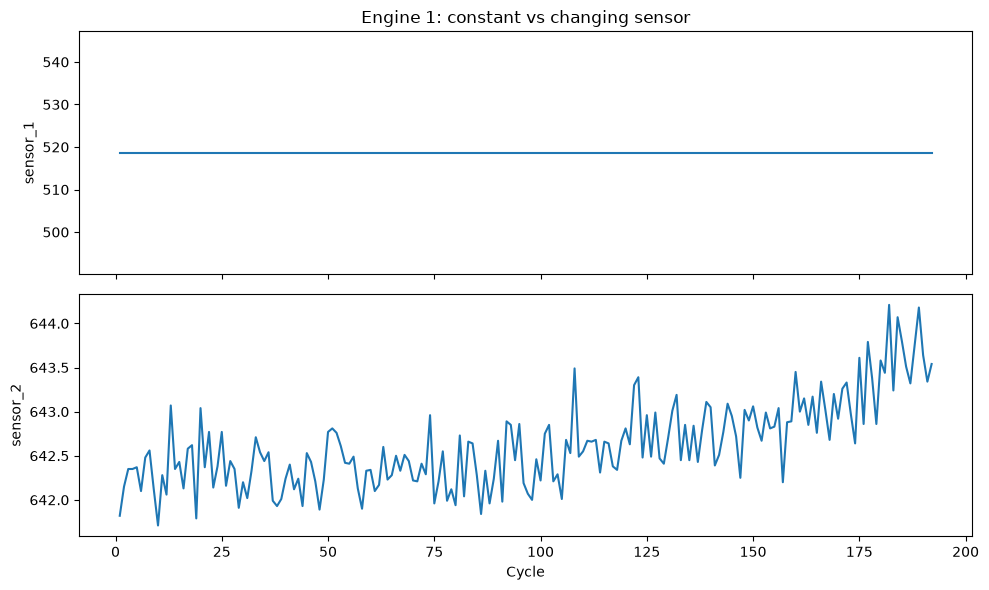

In [6]:
import matplotlib.pyplot as plt

engine_data = train.loc[train["unit_id"] == 1].sort_values("cycle")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(engine_data["cycle"], engine_data["sensor_1"])
axes[0].set_ylabel("sensor_1")
axes[0].set_title("Engine 1: constant vs changing sensor")

axes[1].plot(engine_data["cycle"], engine_data["sensor_2"])
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("sensor_2")

plt.tight_layout()
plt.show()

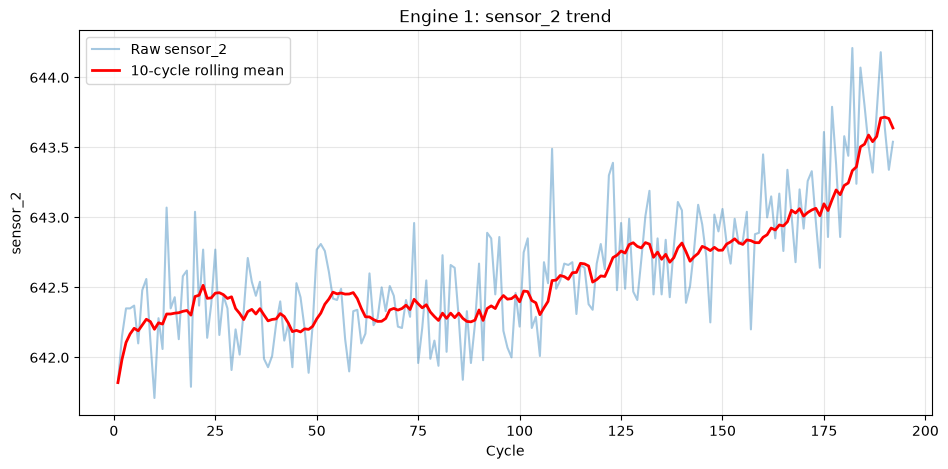

In [7]:
engine_data = train.loc[train["unit_id"] == 1].sort_values("cycle").copy()

engine_data["sensor_2_rolling_mean"] = (
    engine_data["sensor_2"]
    .rolling(window=10, min_periods=1)
    .mean()
)

plt.figure(figsize=(11, 5))

plt.plot(
    engine_data["cycle"],
    engine_data["sensor_2"],
    label="Raw sensor_2",
    alpha=0.4
)

plt.plot(
    engine_data["cycle"],
    engine_data["sensor_2_rolling_mean"],
    label="10-cycle rolling mean",
    color="red",
    linewidth=2
)

plt.xlabel("Cycle")
plt.ylabel("sensor_2")
plt.title("Engine 1: sensor_2 trend")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
train["max_cycle"] = train.groupby("unit_id")["cycle"].transform("max")
train["RUL"] = train["max_cycle"] - train["cycle"]

print(train[["unit_id", "cycle", "max_cycle", "RUL"]].head())

last_rows = train.groupby("unit_id").tail(1)

print("\nNumber of engines:", train["unit_id"].nunique())
print("Number of final rows:", len(last_rows))
print("RUL values in final rows:", last_rows["RUL"].unique())
print("Minimum RUL:", train["RUL"].min())
print("Maximum RUL:", train["RUL"].max())

   unit_id  cycle  max_cycle  RUL
0        1      1        192  191
1        1      2        192  190
2        1      3        192  189
3        1      4        192  188
4        1      5        192  187

Number of engines: 100
Number of final rows: 100
RUL values in final rows: [0]
Minimum RUL: 0
Maximum RUL: 361


count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


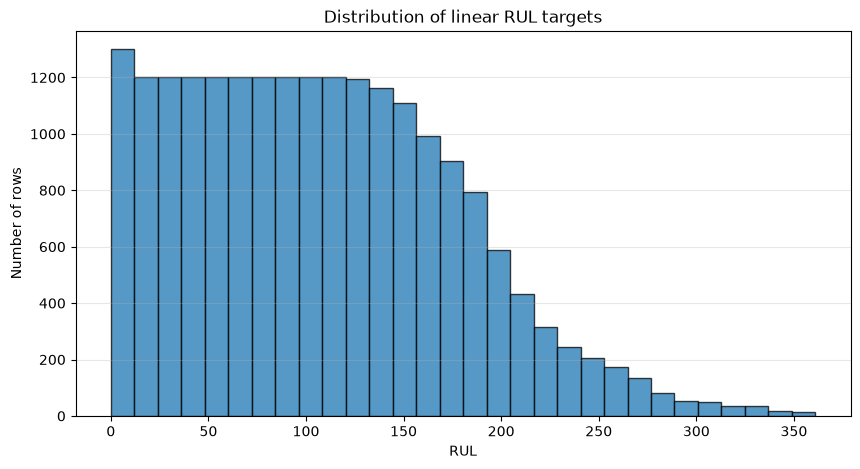

In [9]:
print(train["RUL"].describe())

plt.figure(figsize=(10, 5))
plt.hist(
    train["RUL"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.xlabel("RUL")
plt.ylabel("Number of rows")
plt.title("Distribution of linear RUL targets")
plt.grid(axis="y", alpha=0.3)
plt.show()

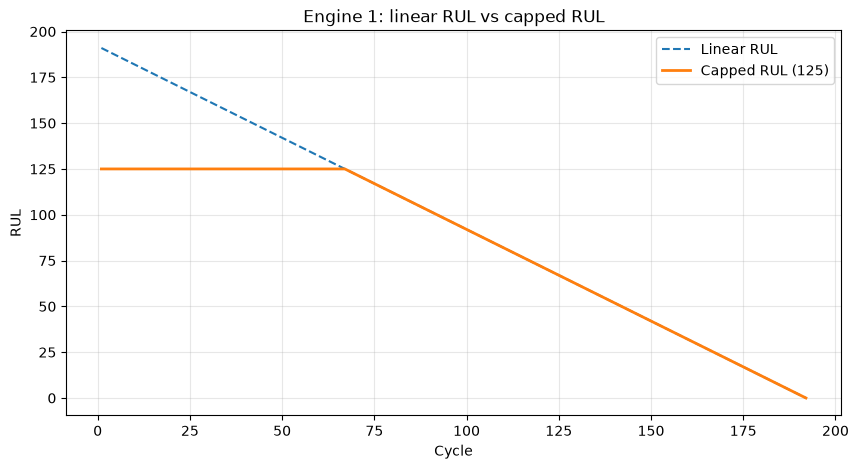

     cycle  RUL  RUL_capped
0        1  191         125
50      51  141         125
66      67  125         125
67      68  124         124
100    101   91          91
191    192    0           0


In [10]:
RUL_CAP = 125

train["RUL_capped"] = train["RUL"].clip(upper=RUL_CAP)

engine_1_targets = train.loc[train["unit_id"] == 1]

plt.figure(figsize=(10, 5))

plt.plot(
    engine_1_targets["cycle"],
    engine_1_targets["RUL"],
    label="Linear RUL",
    linestyle="--"
)

plt.plot(
    engine_1_targets["cycle"],
    engine_1_targets["RUL_capped"],
    label="Capped RUL (125)",
    linewidth=2
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("Engine 1: linear RUL vs capped RUL")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(
    engine_1_targets[
        ["cycle", "RUL", "RUL_capped"]
    ].iloc[[0, 50, 66, 67, 100, -1]]
)

sensor_11   -0.775230
sensor_4    -0.757157
sensor_15   -0.720858
sensor_17   -0.680829
sensor_2    -0.678458
sensor_3    -0.655030
sensor_8    -0.624568
sensor_13   -0.624034
sensor_9    -0.462151
sensor_14   -0.369753
sensor_6    -0.108289
sensor_20    0.704626
sensor_21    0.707334
sensor_7     0.733021
sensor_12    0.748870
Name: RUL_capped, dtype: float64


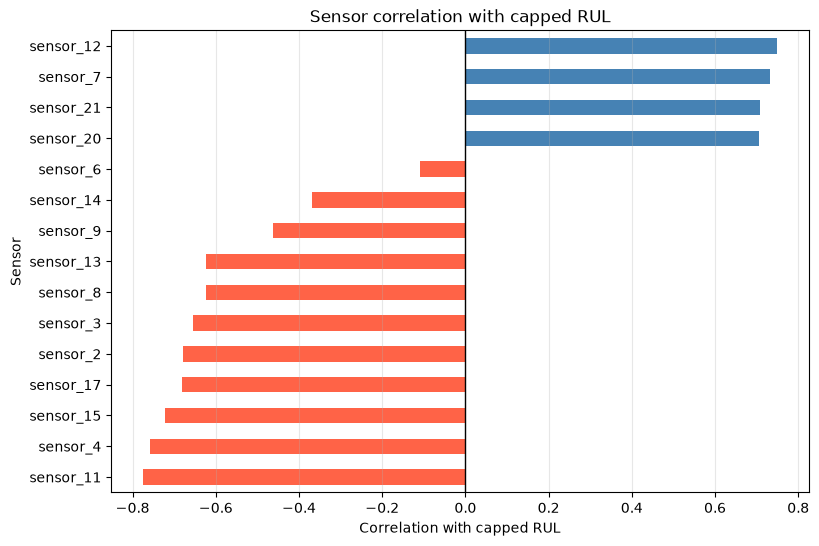

In [11]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

non_constant_sensors = [
    col for col in sensor_cols
    if train[col].nunique() > 1
]

sensor_correlations = (
    train[non_constant_sensors + ["RUL_capped"]]
    .corr()["RUL_capped"]
    .drop("RUL_capped")
    .sort_values()
)

print(sensor_correlations)

plt.figure(figsize=(9, 6))
sensor_correlations.plot(
    kind="barh",
    color=[
        "tomato" if value < 0 else "steelblue"
        for value in sensor_correlations
    ]
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlation with capped RUL")
plt.ylabel("Sensor")
plt.title("Sensor correlation with capped RUL")
plt.grid(axis="x", alpha=0.3)
plt.show()

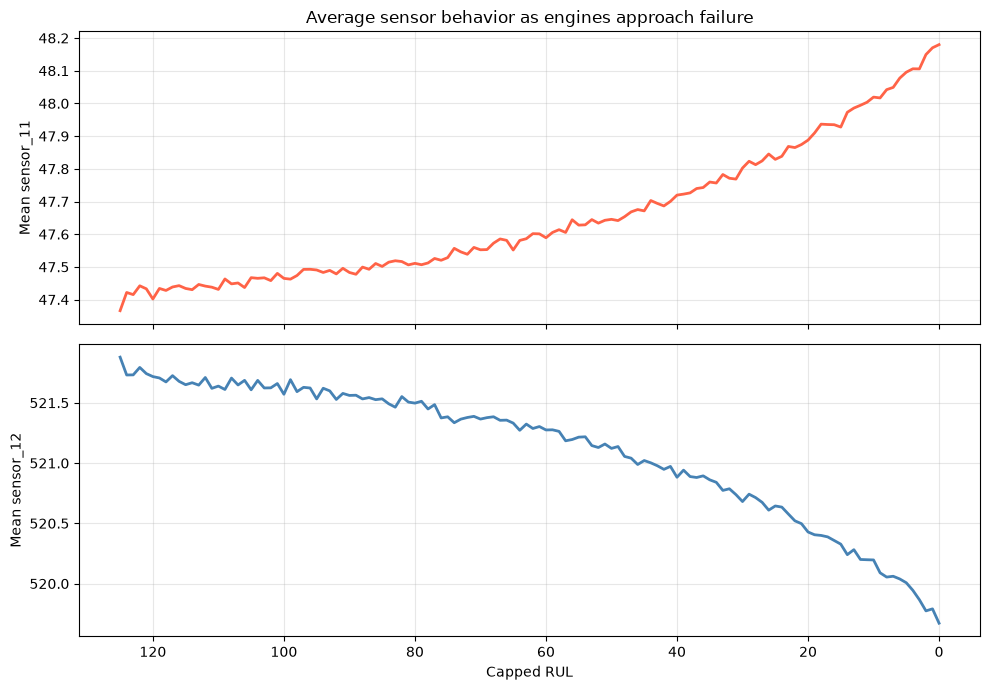

In [12]:
mean_sensors_by_rul = (
    train.groupby("RUL_capped")[["sensor_11", "sensor_12"]]
    .mean()
    .sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(
    mean_sensors_by_rul.index,
    mean_sensors_by_rul["sensor_11"],
    color="tomato",
    linewidth=2
)
axes[0].set_ylabel("Mean sensor_11")
axes[0].set_title("Average sensor behavior as engines approach failure")
axes[0].grid(alpha=0.3)

axes[1].plot(
    mean_sensors_by_rul.index,
    mean_sensors_by_rul["sensor_12"],
    color="steelblue",
    linewidth=2
)
axes[1].set_xlabel("Capped RUL")
axes[1].set_ylabel("Mean sensor_12")
axes[1].grid(alpha=0.3)

# Soldan sağa ilerledikçe failure noktasına yaklaşalım.
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

            train        test
count  100.000000  100.000000
mean   206.310000  130.960000
std     46.342749   53.593479
min    128.000000   31.000000
25%    177.000000   88.750000
50%    199.000000  133.500000
75%    229.250000  164.250000
max    362.000000  303.000000


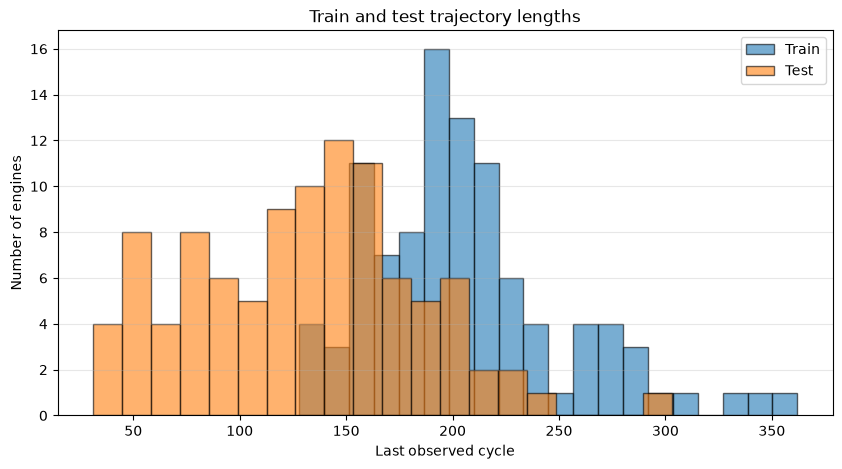

In [13]:
train_lengths = train.groupby("unit_id")["cycle"].max()
test_lengths = test.groupby("unit_id")["cycle"].max()

length_summary = pd.DataFrame({
    "train": train_lengths.describe(),
    "test": test_lengths.describe()
})

print(length_summary)

plt.figure(figsize=(10, 5))

plt.hist(
    train_lengths,
    bins=20,
    alpha=0.6,
    label="Train",
    edgecolor="black"
)

plt.hist(
    test_lengths,
    bins=20,
    alpha=0.6,
    label="Test",
    edgecolor="black"
)

plt.xlabel("Last observed cycle")
plt.ylabel("Number of engines")
plt.title("Train and test trajectory lengths")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

First 5 test engines:
   unit_id  last_observed_cycle  true_RUL  inferred_failure_cycle
0        1                   31       112                     143
1        2                   49        98                     147
2        3                  126        69                     195
3        4                  106        82                     188
4        5                   98        91                     189

Train and test total lifespan summary:
       train_failure_cycle  test_inferred_failure_cycle
count           100.000000                   100.000000
mean            206.310000                   206.480000
std              46.342749                    44.041872
min             128.000000                   141.000000
25%             177.000000                   174.750000
50%             199.000000                   199.000000
75%             229.250000                   227.750000
max             362.000000                   341.000000


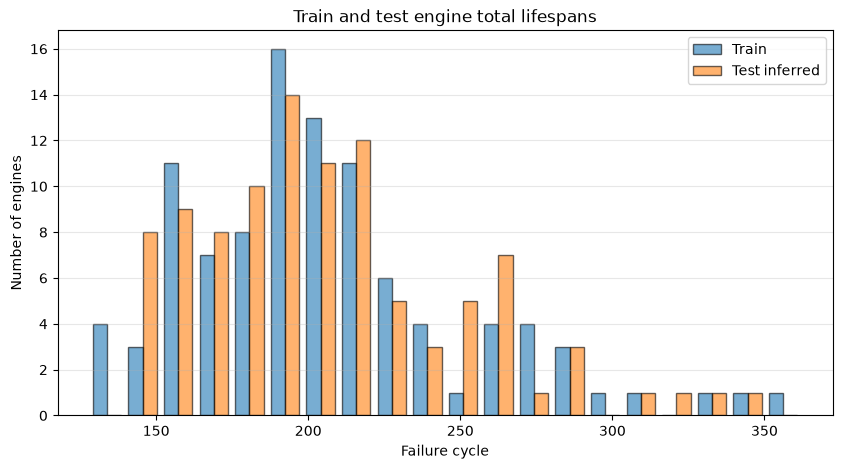

In [14]:
test_summary = test_lengths.rename("last_observed_cycle").reset_index()

# RUL dosyasındaki satırlar test motorlarının unit_id sırasıyla eşleşir.
test_summary["true_RUL"] = rul["RUL"].to_numpy()

test_summary["inferred_failure_cycle"] = (
    test_summary["last_observed_cycle"]
    + test_summary["true_RUL"]
)

print("First 5 test engines:")
print(test_summary.head())

lifespan_summary = pd.DataFrame({
    "train_failure_cycle": train_lengths.describe(),
    "test_inferred_failure_cycle": (
        test_summary["inferred_failure_cycle"].describe()
    )
})

print("\nTrain and test total lifespan summary:")
print(lifespan_summary)

plt.figure(figsize=(10, 5))

plt.hist(
    [
        train_lengths,
        test_summary["inferred_failure_cycle"]
    ],
    bins=20,
    alpha=0.6,
    label=["Train", "Test inferred"],
    edgecolor="black"
)

plt.xlabel("Failure cycle")
plt.ylabel("Number of engines")
plt.title("Train and test engine total lifespans")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Summary

- FD001 contains 100 training engines and 100 test engines.
- Each row represents one engine at one operational cycle.
- The data contains no missing values or duplicate unit-cycle pairs.
- Training trajectories continue until failure, while test trajectories stop before failure.
- The RUL target was calculated as `max_cycle - cycle` for each training engine.
- A capped RUL target of 125 cycles was created as an initial modeling assumption.
- Several constant features were identified and will be excluded from modeling.
- `sensor_11` and `sensor_12` show strong degradation patterns in opposite directions.
- Train and test engines have similar total lifespan distributions.
- Ground-truth test RUL values will be used only for final evaluation.